# Data visualization and classification in `scikit-learn` & `matplotlib`

In [1]:
# Check for all needed packages
import numpy
import matplotlib
import mnists
import sklearn
import plotly
import nbformat
# In case of ImportError, install them to the running kernel with
# %pip install numpy matplotlib mnists scikit-learn plotly nbformat
# or the the runtime container with:
# !pip install numpy matplotlib mnists scikit-learn plotly nbformat
# (In case of the latter, remember to restart the kernel!)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1234)

# import mkl
# mkl.set_num_threads(2)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

In [4]:
def arrange_tiles_img(examples: np.array) -> np.array:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count, cols_count, tile_height, tile_width = examples.shape

    space_between_tiles = 2
    img_matrix = np.empty(shape=(
        rows_count * (tile_height + space_between_tiles) - space_between_tiles,
        cols_count * (tile_width + space_between_tiles) - space_between_tiles
    ))
    img_matrix.fill(np.nan)

    for y in range(rows_count):
        for x in range(cols_count):
            start_y = y * (tile_height + space_between_tiles)
            start_x = x * (tile_width + space_between_tiles)
            img_matrix[start_y : start_y + tile_height, start_x : start_x + tile_width] = examples[y, x]

    return img_matrix

## MNIST Dataset

Import and visualistion of the MNIST dataset with the auxiliary `arrange_tiles_img()` function.

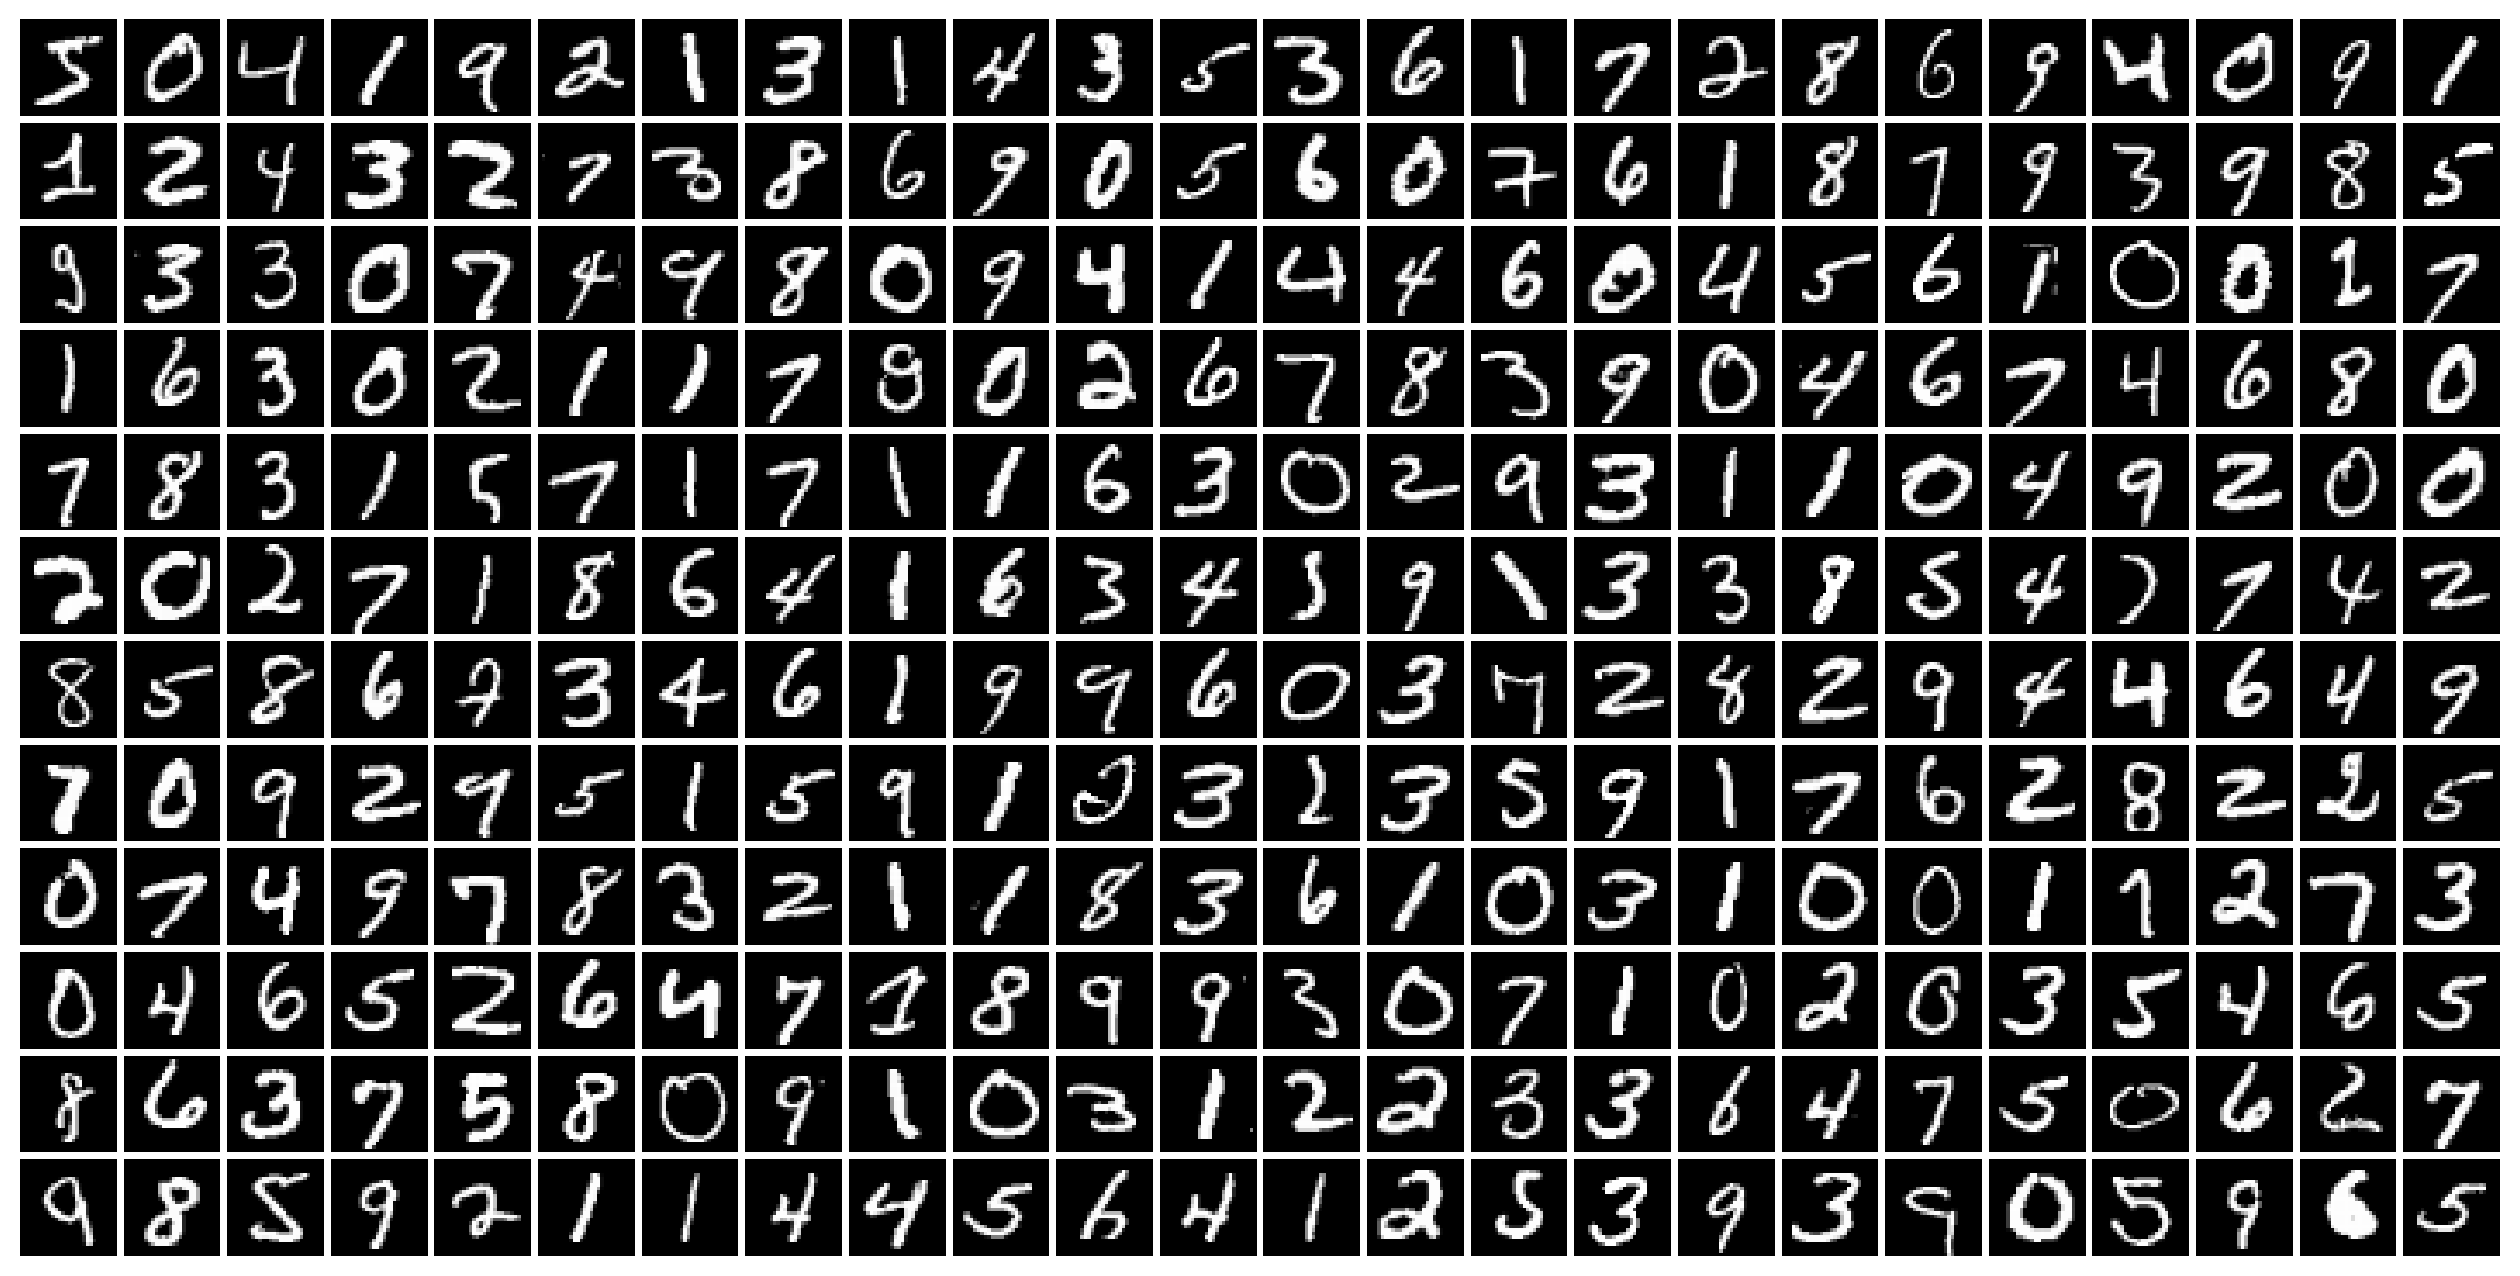

In [5]:
from mnists import MNIST
mnist = MNIST()

n_rows = 12
n_cols = 24
tile_dim = 28 # [px]
shape = (n_rows, n_cols, tile_dim, tile_dim)
mnist_digits = np.reshape(mnist.train_images()[:12*24], newshape=shape)

tiles_img = arrange_tiles_img(mnist_digits)

plt.matshow(tiles_img, cmap='gray', interpolation='none')
plt.axis('off')
plt.show()

In [6]:
X = mnist.train_images().astype(np.float32) / 255.0 # Data normalization from [0, 255] to [0.0, 1.0]
y = mnist.train_labels()
X.shape

(60000, 28, 28)

Reshape `X` so that the last two dimensions are collapsed into single dimension.

In [9]:
X = X.reshape(X.shape[0], 28 * 28)
X.shape

(60000, 784)

## Visualizing the distribution of MNIST digits

Add a scatter plot to `plot`, which:
* displys the first two dimensions of `X`,
* includes only these elements from `X` for which `y == i` (i.e. elements from the i-th class),
* includes label (i.e. `i`) in the legend.


In [10]:
def plot_2d_mnist_scatter(X: np.array, y: np.array) -> None:
    fig, plot = plt.subplots()
    fig.set_size_inches(16, 16)
    plt.prism()

    for i in range(10):
        digit_indices = np.where(y == i)
        dim1 = X[digit_indices, 0]
        dim2 = X[digit_indices, 1]
        plot.scatter(dim1, dim2, label=str(i))
    #

    plot.set_xticks(())
    plot.set_yticks(())

    plt.tight_layout()
    plt.legend()
    plt.show()
#

### Principal Component Analysis (PCA)

In [11]:
# Creating a small subset of the MNIST dataset for faster preview computation
SAMPLES_LIMIT = 2000
X_small = X[:SAMPLES_LIMIT]
y_small = y[:SAMPLES_LIMIT]

Use PCA function to embed `X_small` in two dimensions. Store the result in `X_pca_embedded`.

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
X_pca_embedded = pca.fit_transform(X_small)

X_pca_embedded.shape

(2000, 2)

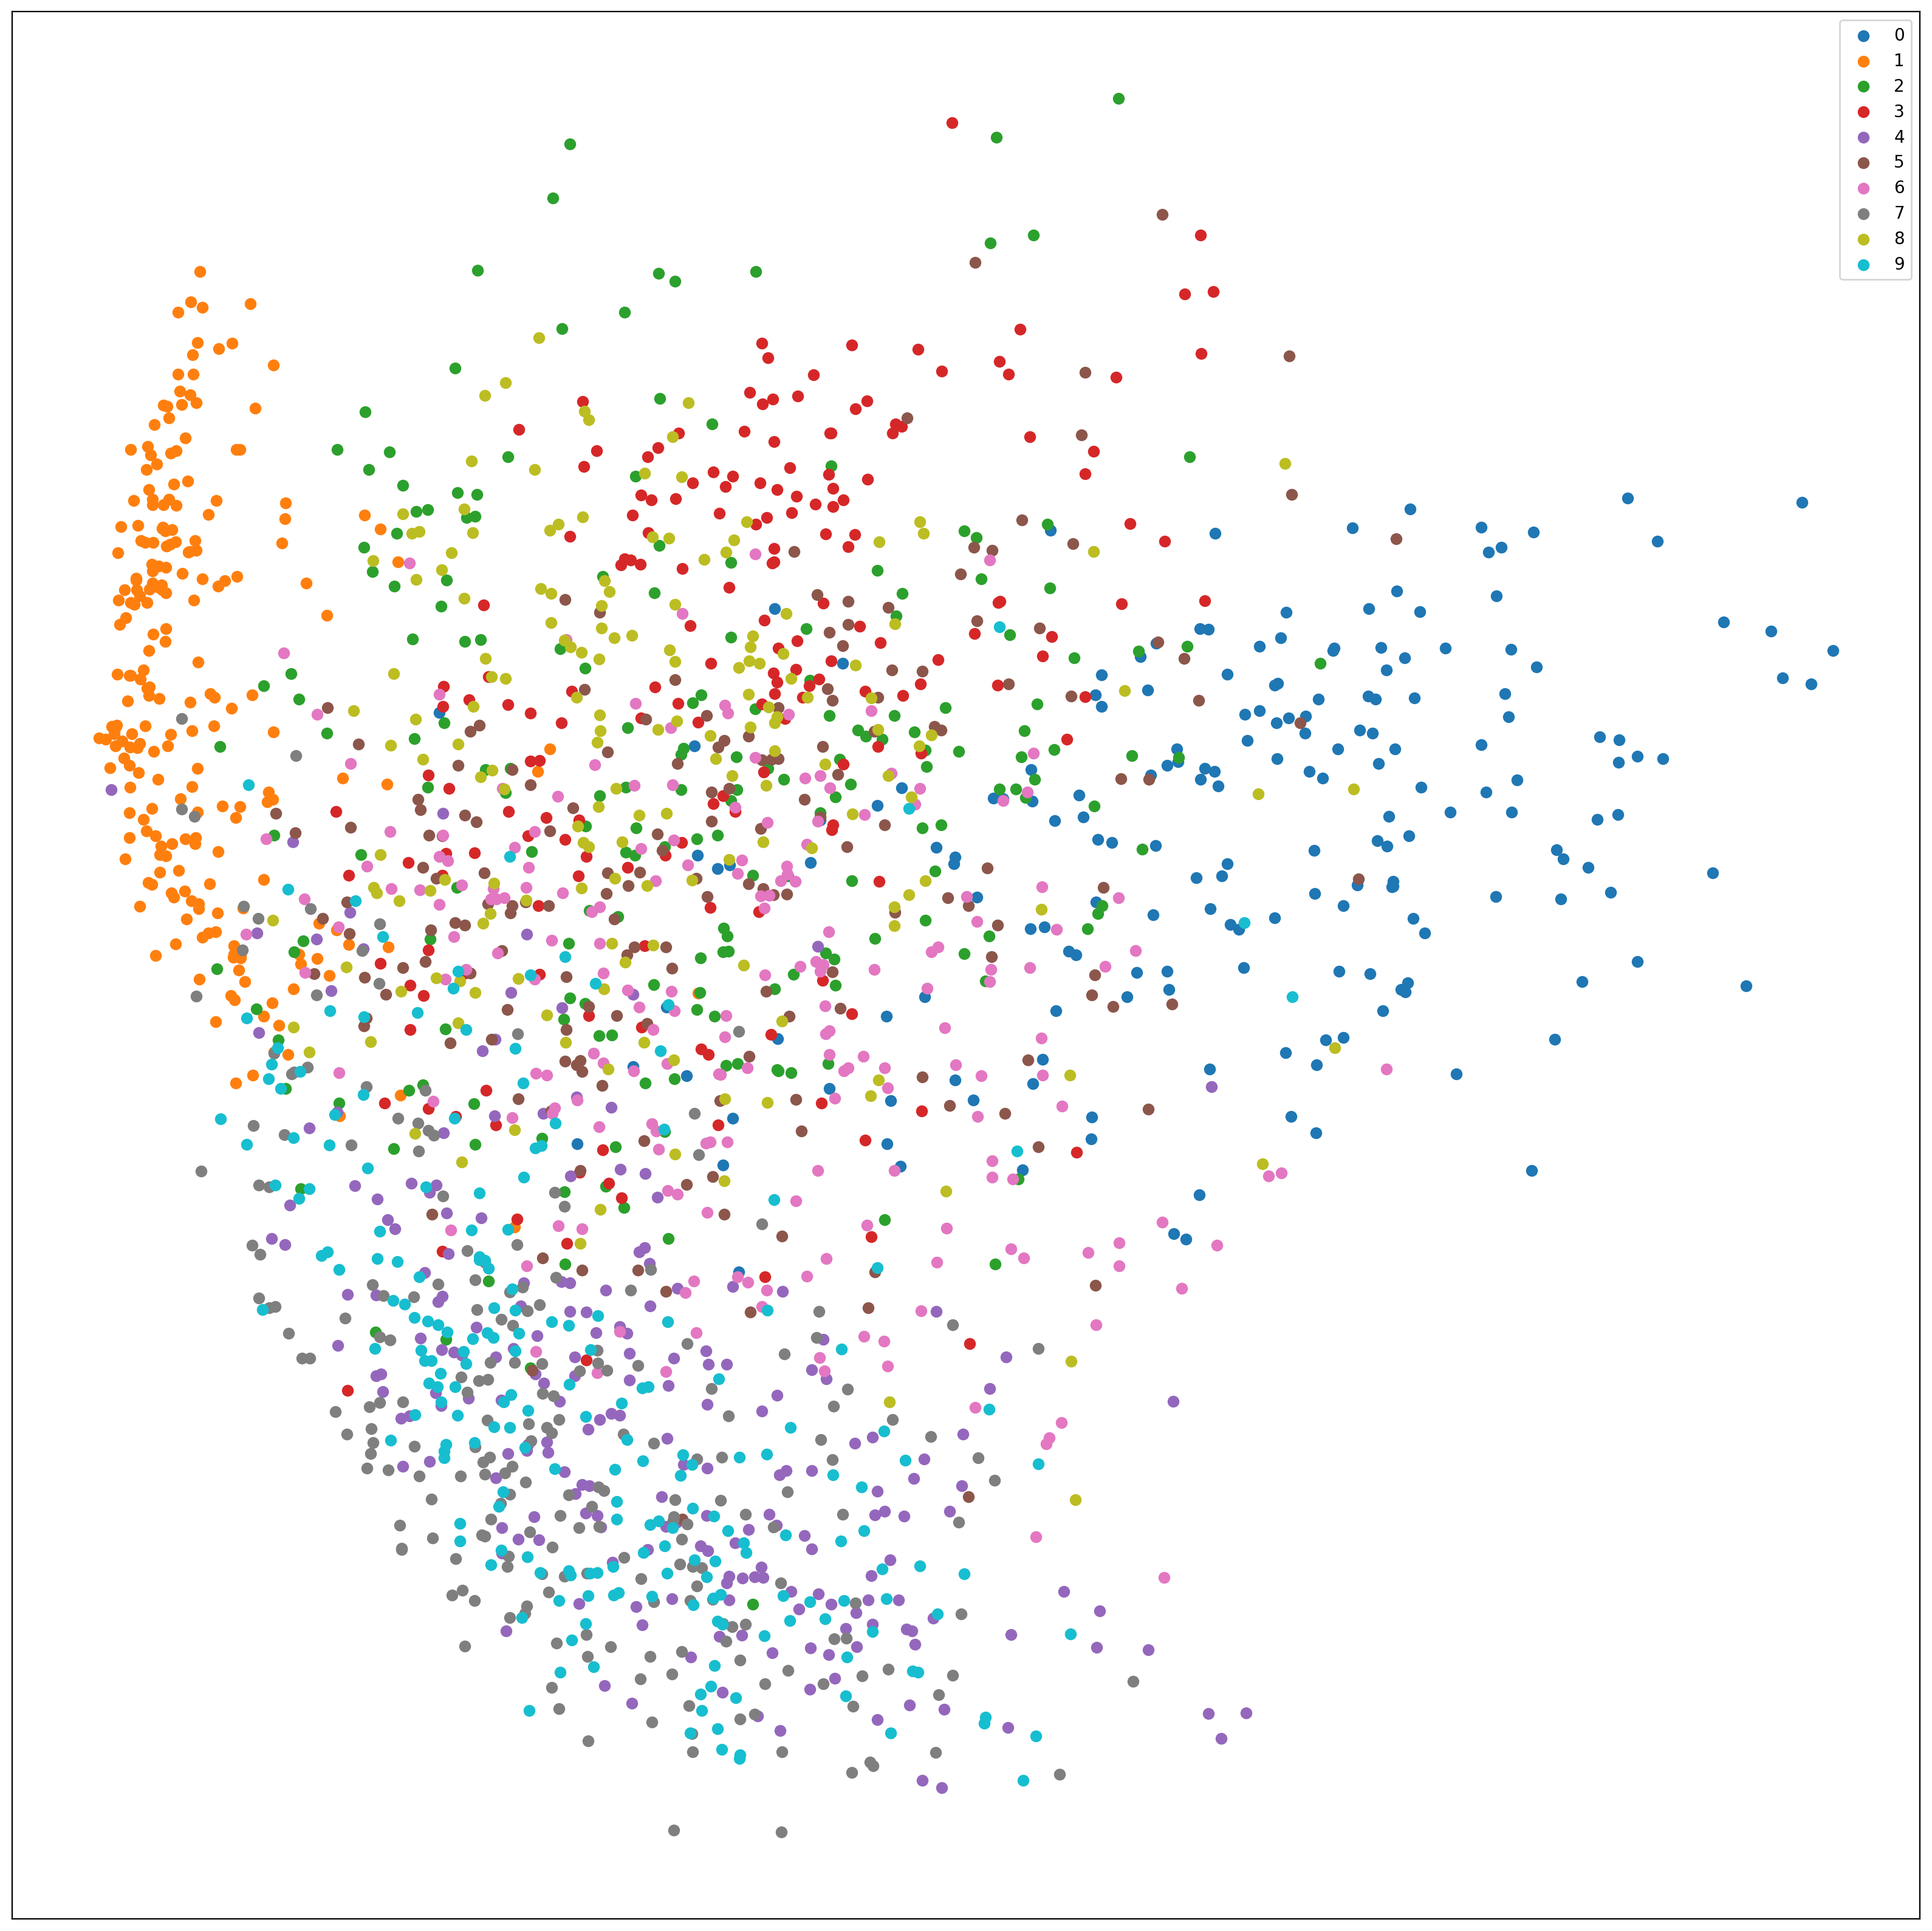

In [16]:
plot_2d_mnist_scatter(X_pca_embedded, y_small)

### T-distributed Stochastic Neighbour Embedding (T-SNE)

Make sure to have a look on this increadible [article on T-SNE](https://distill.pub/2016/misread-tsne/).

Use `T-SNE` function to embed `X_small` in two dimensions. Store the result in `X_tsne_embedded`. <BR>
Use:
 * `n_components=2` argument to setup the dimension of the embedded space,
 * `n_iter=500` or `max_iter=500` argument to limit the number of T-SNE iterations, 
 * `verbose=2` argument to see a verbose output during embedding.

In [17]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, max_iter=500, verbose=2, random_state=0)
X_tsne_embedded = tsne.fit_transform(X_small)

X_tsne_embedded.shape

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.000s...
[t-SNE] Computed neighbors for 2000 samples in 0.494s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 2.528207
[t-SNE] Computed conditional probabilities in 0.071s
[t-SNE] Iteration 50: error = 77.8458786, gradient norm = 0.0140688 (50 iterations in 0.561s)
[t-SNE] Iteration 100: error = 75.6781158, gradient norm = 0.0004026 (50 iterations in 0.462s)
[t-SNE] Iteration 150: error = 75.6541901, gradient norm = 0.0007390 (50 iterations in 0.483s)
[t-SNE] Iteration 200: error = 75.5951462, gradient norm = 0.0007273 (50 iterations in 0.443s)
[t-SNE] Iteration 250: error = 75.5493546, gradient norm = 0.0002910 (50 iterations in 0.757s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 75.549355
[t-SNE] Iteration 300: error = 1.7911223, gradient norm = 0.0210374 (50 iterations in 0.955s)

(2000, 2)

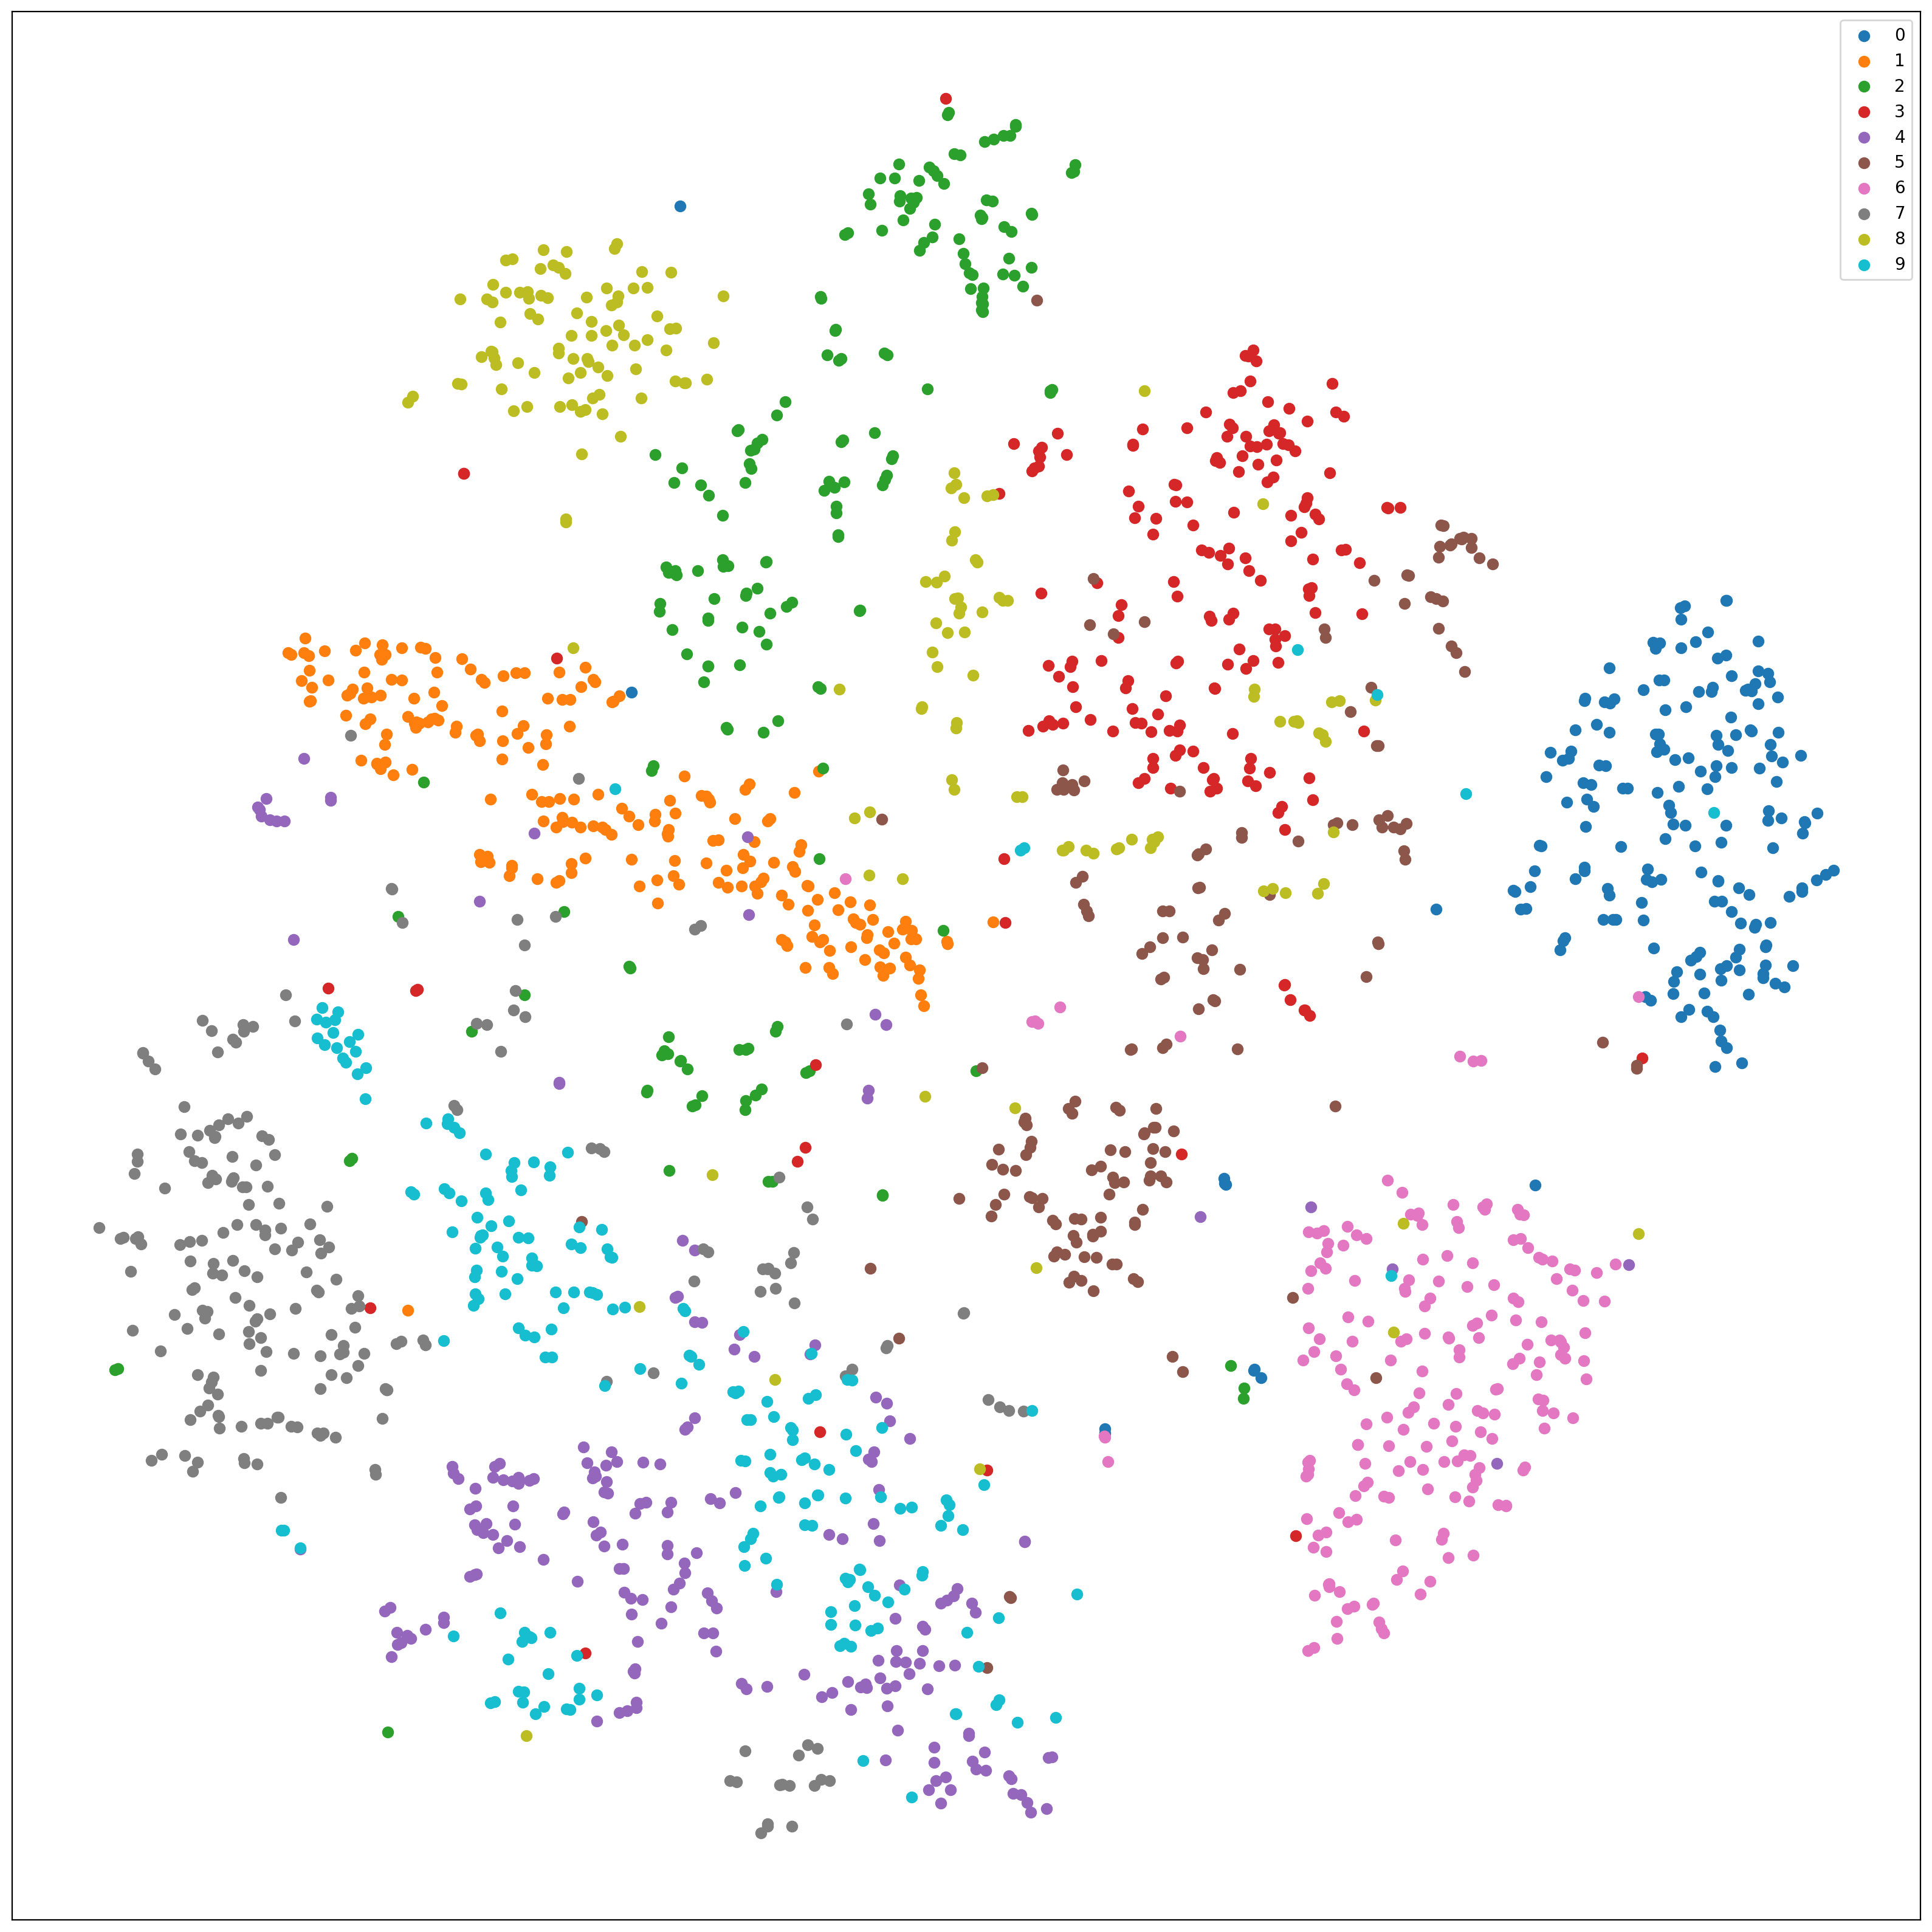

In [18]:
plot_2d_mnist_scatter(X_tsne_embedded, y_small)

### 3D interactive plots with plotly

In [29]:
import plotly.graph_objs as go
import plotly.io as pio

pio.renderers.default = "notebook"

def plot_3d_mnist_plotly_scatter(X, y):
    def make_trace(i):
        digit_indices = y == i
        return go.Scatter3d(
            x=X[digit_indices, 0],
            y=X[digit_indices, 1],
            z=X[digit_indices, 2],
            mode='markers',
            name=str(i),
            marker=dict(
                color=i,
                colorscale='Jet',
                size=3,
                symbol='circle',
                line=dict(color='rgb(204, 204, 204)', width=1)
            )
        )

    traces = [make_trace(i) for i in range(10)]
    layout = go.Layout(margin=dict(l=0, r=0, b=0, t=0))
    fig = go.Figure(data=traces, layout=layout)
    fig.show()  # ← key change

Use PCA function to embed `X_small` in **three** dimensions. Store the result in `X_3d_pca_embedded`.

In [25]:
pca_3d = PCA(n_components=3, random_state=0)
X_3d_pca_embedded = pca_3d.fit_transform(X_small)

X_3d_pca_embedded.shape

(2000, 3)

In [30]:
plot_3d_mnist_plotly_scatter(X_3d_pca_embedded, y_small)

## Classification task (with SVM)
SVM - Support Vector Machine

In [31]:
from sklearn.model_selection import train_test_split
SAMPLES_LIMIT=10000
X_train, X_test, y_train, y_test = train_test_split(X[:SAMPLES_LIMIT], y[:SAMPLES_LIMIT], test_size=0.2)

In [47]:
from sklearn import svm
classifier = svm.SVC(C=1, gamma=0.001)
classifier.fit(X_train, y_train)

SVC(C=1, gamma=0.001)

In [48]:
from sklearn import metrics

predicted = classifier.predict(X_test)

print(f"Classification report for classifier {classifier}:\n{metrics.classification_report(y_test, predicted)}\n")

Classification report for classifier SVC(C=1, gamma=0.001):
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       178
           1       0.89      0.97      0.93       215
           2       0.90      0.89      0.90       196
           3       0.90      0.85      0.87       190
           4       0.90      0.92      0.91       206
           5       0.88      0.91      0.89       206
           6       0.94      0.98      0.96       202
           7       0.93      0.90      0.91       222
           8       0.96      0.85      0.90       188
           9       0.88      0.89      0.88       197

    accuracy                           0.91      2000
   macro avg       0.92      0.91      0.91      2000
weighted avg       0.92      0.91      0.91      2000




Calculate and display the confision matrix for `predicted` and `y_test` (use metrics package).

In [49]:
import pandas as pd

confusion_matrix = metrics.confusion_matrix(y_test, predicted, labels=range(10))
confusion_matrix_df = pd.DataFrame(confusion_matrix, index=range(10), columns=range(10))

print(confusion_matrix_df)

     0    1    2    3    4    5    6    7    8    9
0  176    0    0    0    2    0    0    0    0    0
1    0  209    2    0    0    2    0    2    0    0
2    2    4  175    1    5    0    3    2    4    0
3    0    3    7  162    0    9    1    3    2    3
4    0    0    1    0  190    0    4    2    0    9
5    0    2    2   10    0  187    3    0    1    1
6    0    0    2    0    0    3  197    0    0    0
7    0    5    1    0    7    0    0  199    0   10
8    0    9    3    4    0   11    0    1  159    1
9    2    2    1    4    6    1    1    5    0  175


## Additonal links

### Refresher of Machine Learning
* [YouTube | ritvikmath | https://www.youtube.com/watch?v=LxcRFNRgLCs](https://www.youtube.com/watch?v=LxcRFNRgLCs)
* [YouTube | StatQuest | Principal Component Analysis (PCA), Step-by-Step](https://www.youtube.com/watch?v=FgakZw6K1QQ)
* [YouTube | StatQuest | Support Vector Machines Part 1 (of 3): Main Ideas!!!](https://www.youtube.com/watch?v=efR1C6CvhmE)
* [YouTube | Intuitive Machine Learning | Support Vector Machines: All you need to know!](https://www.youtube.com/watch?v=ny1iZ5A8ilA)

### Extra material
* [YouTube | StatQuest | t-SNE, Clearly Explained](https://www.youtube.com/watch?v=NEaUSP4YerM)
* [YouTube | StatQuest | UMAP Dimension Reduction, Main Ideas!!!](https://www.youtube.com/watch?v=eN0wFzBA4Sc)
* [YouTube | Deepia | Latent Space Visualisation: PCA, t-SNE, UMAP | Deep Learning Animated](https://www.youtube.com/watch?v=o_cAOa5fMhE)